**Analyse exploratoire (EDA)**

In [2]:
# modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [3]:
# Charger les données
df = pd.read_csv('../data/raw/creditcard.csv')
print(df.head())
print(df.info())
print(df['Class'].value_counts(normalize=True))

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

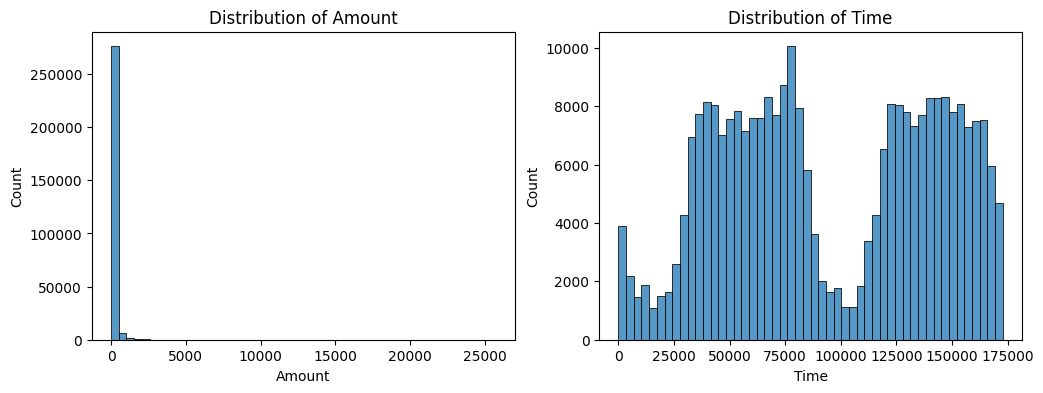

In [6]:
# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['Amount'], bins=50, ax=axes[0])
axes[0].set_title('Distribution of Amount')
sns.histplot(df['Time'], bins=50, ax=axes[1])
axes[1].set_title('Distribution of Time')
plt.show()

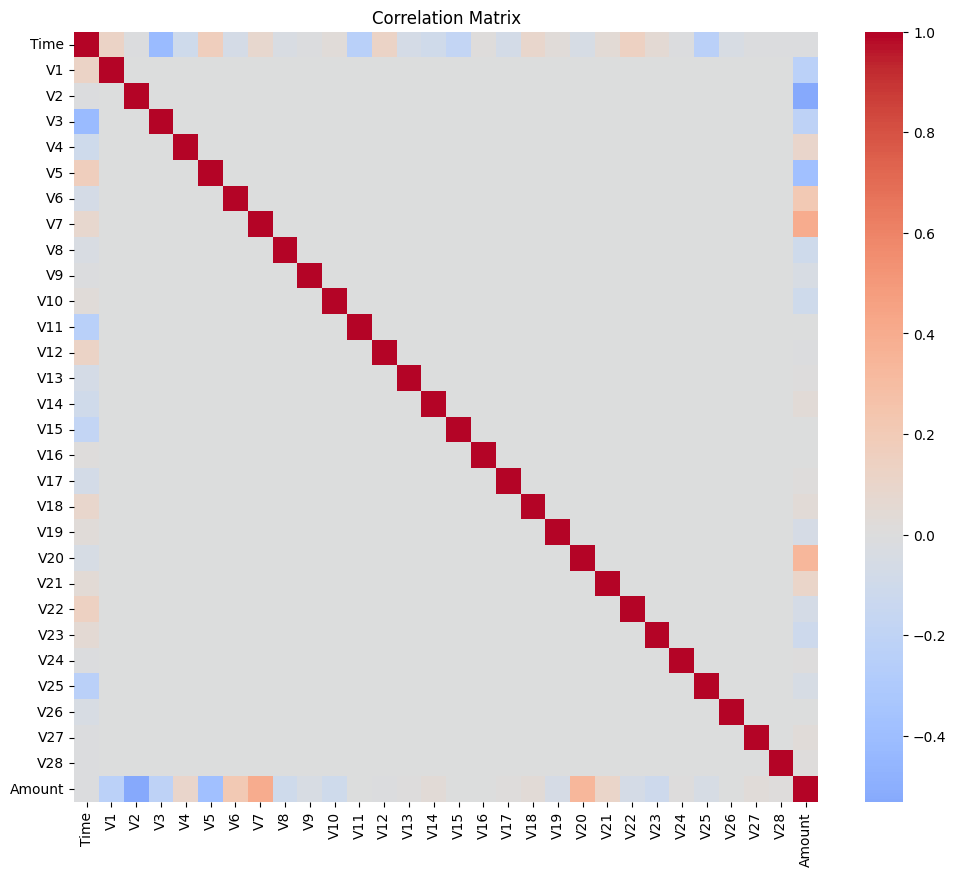

In [8]:
# Matrice de corrélation (uniquement sur les features PCA)
corr = df.iloc[:, :-1].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

In [9]:
# Vérifier les valeurs manquantes
print(df.isnull().sum().sum()) 

0


In [10]:
# Proportion de fraudes
fraud_ratio = df['Class'].mean()
print(f"Fraud ratio: {fraud_ratio:.6f}")

Fraud ratio: 0.001727


In [11]:
# Baseline simple : Logistic Regression avec validation croisée
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve, auc, roc_auc_score

In [12]:
X = df.drop('Class', axis=1)
y = df['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [13]:
# Standardisation de Amount et Time
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[['Amount', 'Time']] = scaler.fit_transform(X_train[['Amount', 'Time']])
X_test_scaled[['Amount', 'Time']] = scaler.transform(X_test[['Amount', 'Time']])

In [14]:
# Modèle
model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

In [15]:
# Métriques
roc_auc = roc_auc_score(y_test, y_pred_proba)
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall, precision)
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")

ROC-AUC: 0.9722
PR-AUC: 0.7604


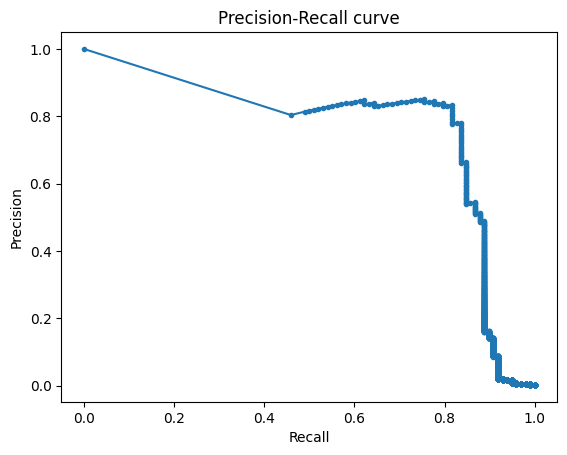

In [16]:
# Courbe PR
plt.figure()
plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curve')
plt.show()

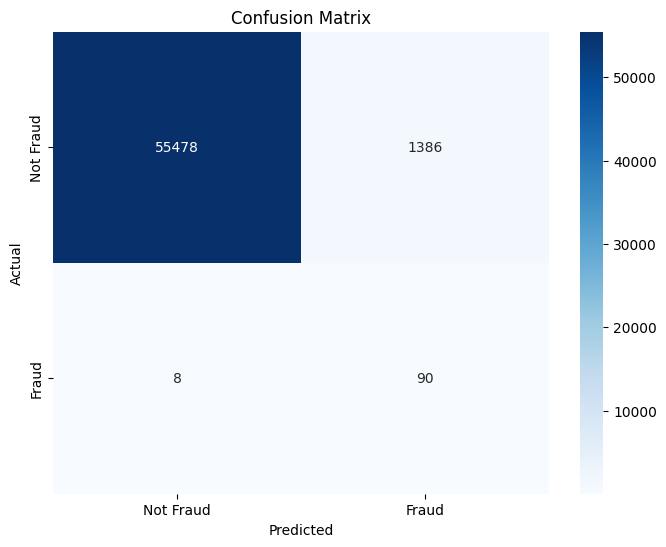

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Predict classes using a threshold of 0.5
y_pred = (y_pred_proba > 0.5).astype(int)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

ROC-AUC RF: 0.9529
PR-AUC RF: 0.8591


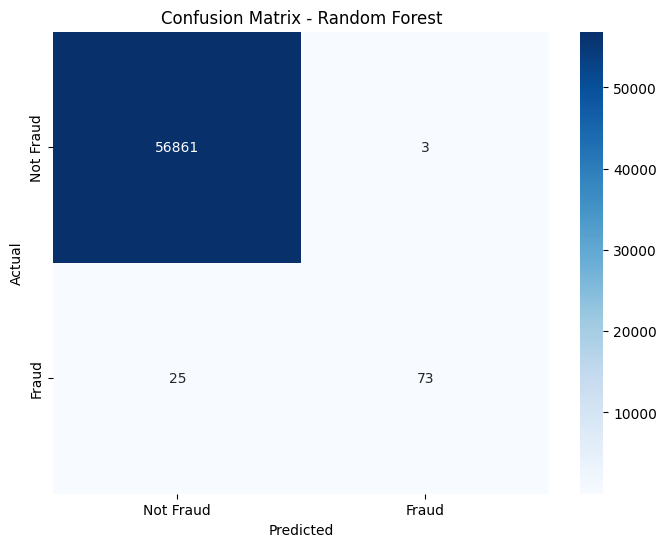

In [18]:
from sklearn.ensemble import RandomForestClassifier

# Modèle Random Forest
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# Métriques
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_pred_proba_rf)
pr_auc_rf = auc(recall_rf, precision_rf)
print(f"ROC-AUC RF: {roc_auc_rf:.4f}")
print(f"PR-AUC RF: {pr_auc_rf:.4f}")

# Matrice de confusion
y_pred_rf = (y_pred_proba_rf > 0.5).astype(int)
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()